# Notes from meeting
- can separate data into students who got A, B, and C and compare other values
- if using colors, use same color scheme for graphs
- Since there are a lot of categorical variables, can make a a Sankey diagram or a treemap

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import altair as alt

C:\Users\rjiang\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [4]:
# Load the dataset
df = pd.read_csv('Factors_ affecting_ university_student_grades_dataset.csv')

# Basic information about the dataset
#print(df.info())

# Display the first few rows of the dataset
df.head()

,Age,Gender,Parental_Education,Family_Income,Previous_Grades,Attendance,Class_Participation,Study_Hours,Major,School_Type,...,Peer_Group,Bullying,Study_Space,Learning_Style,Tutoring,Mentoring,Lack_of_Interest,Time_Wasted_on_Social_Media,Sports_Participation,Grades
0,22.0,F,College,50000.0,A,81.0,Medium,8.0,Law,Private,...,Neutral,NaN,No,Visual,Yes,NaN,Low,2.0,NaN,B
1,21.0,M,NaN,60000.0,A,NaN,Medium,12.0,Law,Public,...,Negative,No,No,Auditory,Yes,Yes,Medium,5.0,High,NaN
2,19.0,M,College,75000.0,C,93.0,Medium,12.0,Law,Private,...,Neutral,No,Yes,NaN,No,No,Low,2.0,High,A
3,21.0,M,College,60000.0,A,86.0,Low,15.0,Business,Public,...,Neutral,No,NaN,Auditory,Yes,Yes,Low,3.0,Medium,C
4,19.0,NaN,NaN,40000.0,NaN,89.0,High,15.0,Medicine,NaN,...,Positive,No,No,Auditory,Yes,NaN,Medium,3.0,High,B


In [5]:
# Summary statistics
print(df.describe())

# Check for missing values
print(df.isnull().sum())

               Age   Attendance  Study_Hours   Class_Size  Sleep_Patterns  \
count  9099.000000  9060.000000  9073.000000  9114.000000     9048.000000   
mean     19.996703    84.908499    12.467761    60.238754        6.538904   
std       1.406885     8.985221     4.613845    23.337209        1.720632   
min      18.000000    70.000000     5.000000    20.000000        4.000000   
25%      19.000000    77.000000     9.000000    40.000000        5.000000   
50%      20.000000    85.000000    12.000000    61.000000        7.000000   
75%      21.000000    93.000000    16.000000    80.000000        8.000000   
max      22.000000   100.000000    20.000000   100.000000        9.000000   

       Screen_Time  Time_Wasted_on_Social_Media  
count  9120.000000                  9137.000000  
mean      6.031469                     3.489329  
std       2.597880                     1.704057  
min       2.000000                     1.000000  
25%       4.000000                     2.000000  
50%   

In [6]:
#import vl_convert as vlc
#print(vlc.__version__)

In [7]:
# Define the mapping
grade_to_gpa = {
    'A': 4.0,
    'B': 3.0,
    'C': 2.0,
    'D': 1.0,
    'F': 0.0
}

# Apply the mapping to the 'Grades' column
df['GPA'] = df['Grades'].map(grade_to_gpa)

# Check the result
print(df[['Grades', 'GPA']].head())

  Grades  GPA
0      B  3.0
1    NaN  NaN
2      A  4.0
3      C  2.0
4      B  3.0


In [8]:
# Data Cleaning: Fill missing values with the mean for numerical columns and mode for categorical columns
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].mean(), inplace=True)

# Check for missing values
print(df.isnull().sum())

Age                            0
Gender                         0
Parental_Education             0
Family_Income                  0
Previous_Grades                0
Attendance                     0
Class_Participation            0
Study_Hours                    0
Major                          0
School_Type                    0
Financial_Status               0
Parental_Involvement           0
Educational_Resources          0
Motivation                     0
Self_Esteem                    0
Stress_Levels                  0
School_Environment             0
Professor_Quality              0
Class_Size                     0
Extracurricular_Activities     0
Sleep_Patterns                 0
Nutrition                      0
Physical_Activity              0
Screen_Time                    0
Educational_Tech_Use           0
Peer_Group                     0
Bullying                       0
Study_Space                    0
Learning_Style                 0
Tutoring                       0
Mentoring 

C:\Users\rjiang\AppData\Local\Temp\ipykernel_27520\977409101.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
C:\Users\rjiang\AppData\Local\Temp\ipykernel_27520\977409101.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

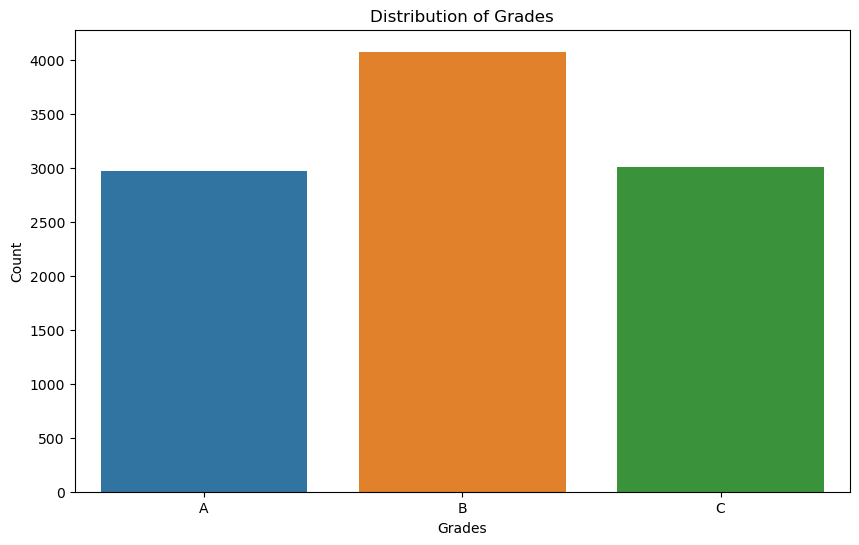

In [9]:
# Visualization 1: Distribution of Grades
grades_list = sorted(df['Grades'].unique())
plt.figure(figsize=(10, 6))
sns.countplot(x='Grades', data=df, order=grades_list)
plt.title('Distribution of Grades')
plt.xlabel('Grades')
plt.ylabel('Count')
plt.savefig("Distribution_of_Grades.png")
plt.show()

<Figure size 1500x600 with 0 Axes>

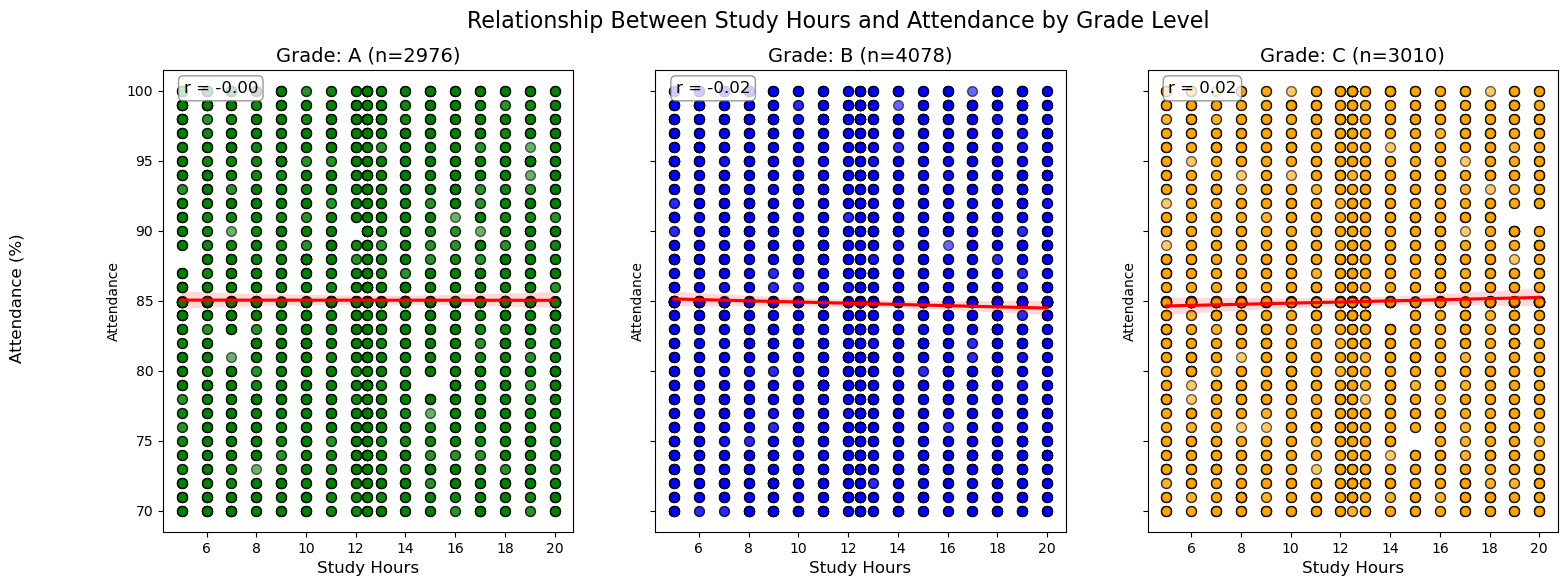

In [10]:
# Create a figure for the scatterplots
plt.figure(figsize=(15, 6))

# Create scatterplots for each grade
# Using subplots for side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True, sharex=True)

# Define colors for better visualization
colors = {'A': 'green', 'B': 'blue', 'C': 'orange'}
grade_labels = ['A', 'B', 'C']

# Create a scatterplot for each grade
for i, grade in enumerate(grade_labels):
    grade_data = df[df["Grades"] == grade]
    
    # Check if data exists for this grade
    if len(grade_data) > 0:
        axes[i].scatter(
            grade_data['Study_Hours'], 
            grade_data['Attendance'],
            alpha=0.6, 
            color=colors.get(grade, 'gray'),
            edgecolor='k',
            s=50
        )
        
        # Add a trend line
        sns.regplot(
            x='Study_Hours', 
            y='Attendance', 
            data=grade_data,
            scatter=False,
            ax=axes[i], 
            color='red'
        )
        
        # Set titles and labels
        axes[i].set_title(f'Grade: {grade} (n={len(grade_data)})', fontsize=14)
        axes[i].set_xlabel('Study Hours', fontsize=12)
        
        # Add correlation coefficient
        corr = grade_data['Study_Hours'].corr(grade_data['Attendance'])
        axes[i].annotate(f'r = {corr:.2f}', xy=(0.05, 0.95), xycoords='axes fraction', 
                        fontsize=12, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

# Set common y-label
fig.text(0.04, 0.5, 'Attendance (%)', va='center', rotation='vertical', fontsize=12)

# Add a main title
plt.suptitle('Relationship Between Study Hours and Attendance by Grade Level', fontsize=16)

# Display the plot
plt.show()

# Save the figure
#plt.savefig('attendance_vs_study_hours_by_grade.png', dpi=300, bbox_inches='tight')

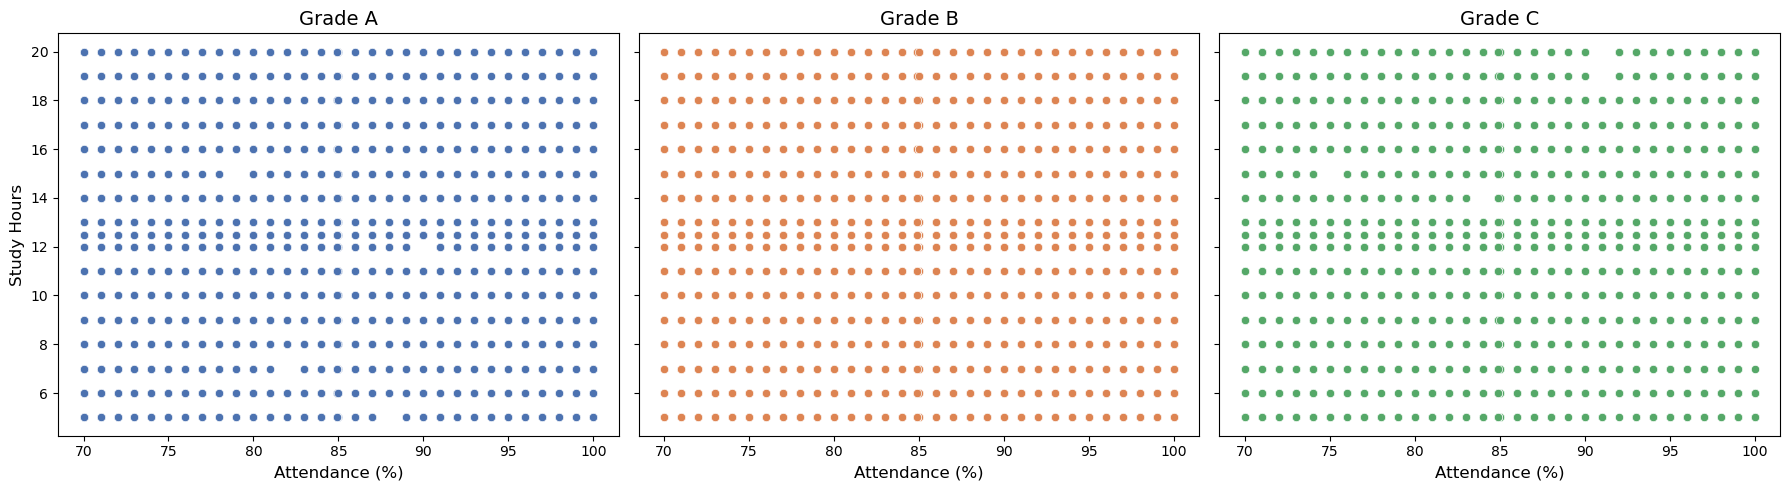

In [11]:
# Define unique grades to filter
grades = ['A', 'B', 'C']

# Set up the figure for subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Loop through each grade and create a scatter plot
for i, grade in enumerate(grades):
    subset = df[df['Grades'] == grade]
    sns.scatterplot(x='Attendance', y='Study_Hours', data=subset, ax=axes[i], color=sns.color_palette("deep")[i])
    axes[i].set_title(f'Grade {grade}', fontsize=14)
    axes[i].set_xlabel('Attendance (%)', fontsize=12)
    if i == 0:
        axes[i].set_ylabel('Study Hours', fontsize=12)
    else:
        axes[i].set_ylabel('')

# Adjust layout and display
plt.tight_layout()
plt.show()

C:\Users\rjiang\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\rjiang\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\rjiang\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


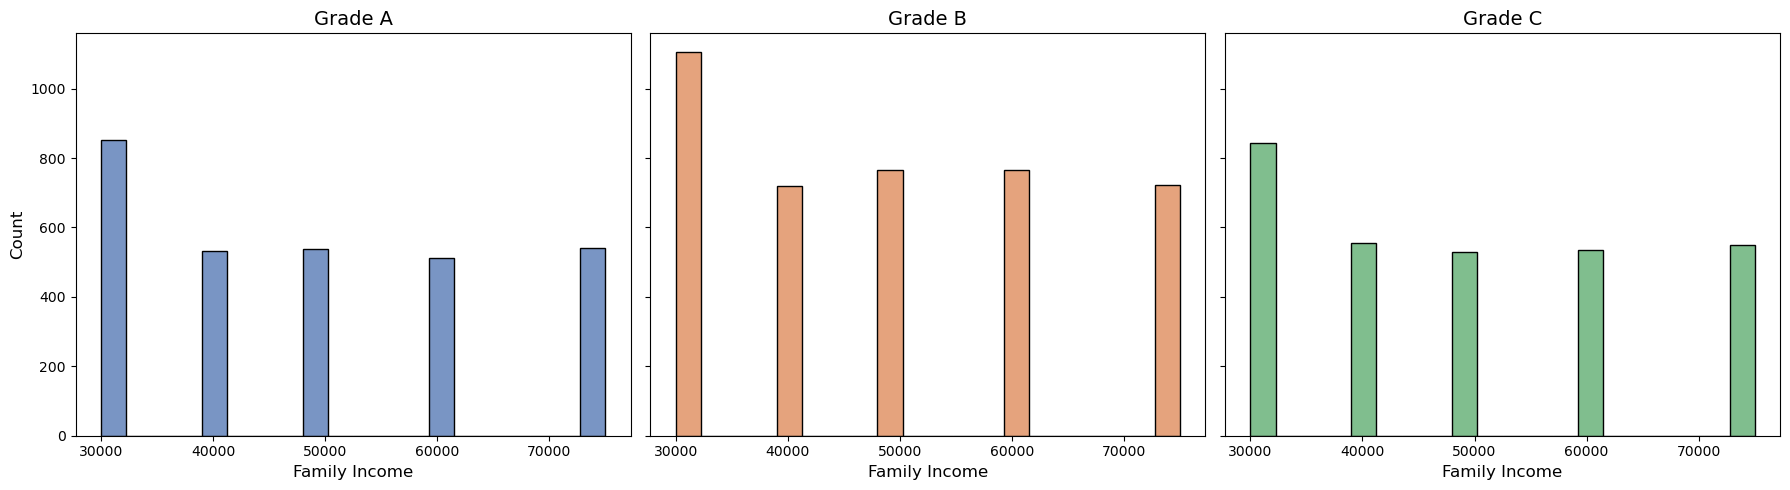

In [12]:
# Ensure 'Family_Income' is numeric, converting errors to NaN
df['Family_Income'] = pd.to_numeric(df['Family_Income'], errors='coerce')
df = df.dropna(subset=['Family_Income'])

# Define unique grades to filter
grades = ['A', 'B', 'C']

# Set up the figure for subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Loop through each grade and create a histogram for sorted Family_Income
for i, grade in enumerate(grades):
    subset = df[df['Grades'] == grade]
    sorted_income = subset['Family_Income'].sort_values()
    
    sns.histplot(sorted_income, bins=20, kde=False, ax=axes[i], color=sns.color_palette("deep")[i])
    axes[i].set_title(f'Grade {grade}', fontsize=14)
    axes[i].set_xlabel('Family Income', fontsize=12)
    if i == 0:
        axes[i].set_ylabel('Count', fontsize=12)
    else:
        axes[i].set_ylabel('')

# Adjust layout and display
plt.tight_layout()
plt.show()

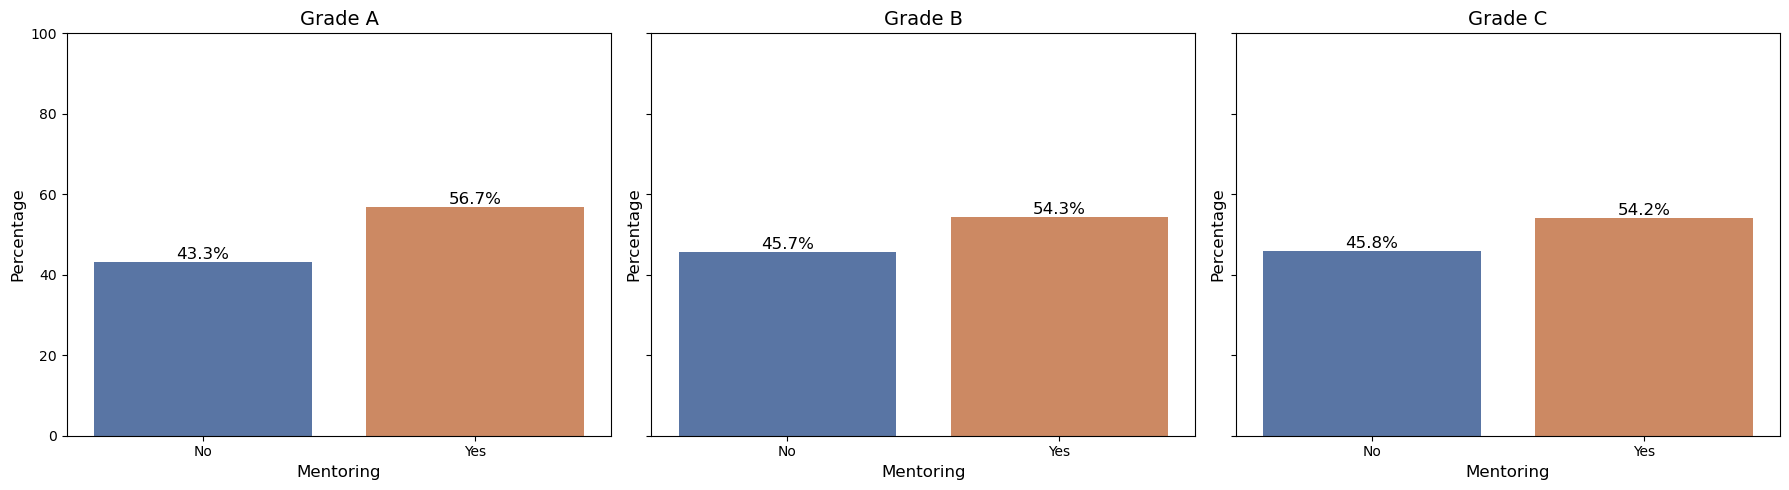

In [13]:
# Ensure the 'Mentoring' column exists and drop missing values
df = df.dropna(subset=['Grades', 'Mentoring'])

# Define unique grades to filter
grades = ['A', 'B', 'C']

# Set up the figure for subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Loop through each grade and create a percentage bar plot for Mentoring
for i, grade in enumerate(grades):
    subset = df[df['Grades'] == grade]

    # Calculate percentage distribution
    mentoring_counts = subset['Mentoring'].value_counts(normalize=True) * 100  # Convert to percentage
    mentoring_percent = mentoring_counts.reindex(['No', 'Yes'], fill_value=0)  # Ensure both categories are present

    # Create bar plot
    sns.barplot(x=mentoring_percent.index, y=mentoring_percent.values, ax=axes[i], palette="deep")
    axes[i].set_title(f'Grade {grade}', fontsize=14)
    axes[i].set_xlabel('Mentoring', fontsize=12)
    axes[i].set_ylabel('Percentage', fontsize=12)
    axes[i].set_ylim(0, 100)  # Set y-axis limit to 100%

    # Add percentage labels on bars
    for p, percentage in zip(axes[i].containers[0], mentoring_percent.values):
        axes[i].annotate(f'{percentage:.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()), 
                         ha='center', va='bottom', fontsize=12)

# Adjust layout and display
#plt.savefig("mentoring_by_grade.png")
plt.tight_layout()
plt.show()

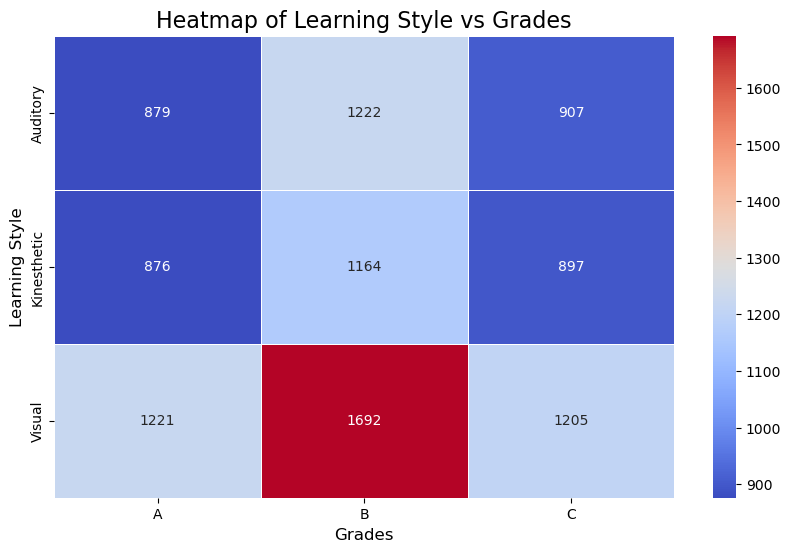

In [14]:
# Create a crosstab of Learning_Style vs Grades
cross_tab = pd.crosstab(df['Learning_Style'], df['Grades'])

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='coolwarm', linewidths=0.5)

# Add labels and title
plt.title('Heatmap of Learning Style vs Grades', fontsize=16)
plt.xlabel('Grades', fontsize=12)
plt.ylabel('Learning Style', fontsize=12)

# Show the plot
#plt.savefig("grades_learning_style_heatmap.png")
plt.show()

In [29]:
import pandas as pd
import plotly.graph_objects as go

# Aggregate data to get percentage of "Yes" for each factor by grade
summary_df = df.groupby("Grades").agg({
    "Mentoring": lambda x: (x == "Yes").mean() * 100,
    "Tutoring": lambda x: (x == "Yes").mean() * 100,
    "Educational_Resources": lambda x: (x == "Yes").mean() * 100
}).reset_index()

# Melt the dataframe to long format
summary_df = summary_df.melt(id_vars="Grades", var_name="Factor", value_name="Percentage")

# Grade color mapping
grade_colors = {"A": "green", "B": "gold", "C": "red"}

# Create one set of traces per factor, with 3 bars (one per grade)
factors = summary_df["Factor"].unique()
traces = []
for factor in factors:
    df_factor = summary_df[summary_df["Factor"] == factor]
    trace = go.Bar(
        x=df_factor["Grades"],
        y=df_factor["Percentage"],
        marker_color=[grade_colors[grade] for grade in df_factor["Grades"]],
        text=df_factor["Percentage"].round(1),
        textposition="outside",
        name=factor,
        visible=(factor == factors[0])  
    )
    traces.append(trace)

# Radio buttons to toggle between factors
buttons = []
for i, factor in enumerate(factors):
    visibility = [j == i for j in range(len(factors))]
    buttons.append(dict(label=factor, method="update", args=[{"visible": visibility}]))

# Create and show figure
fig = go.Figure(data=traces)
fig.update_layout(
    title="Percentage of Student Participation in Academic Support Activities",
    xaxis_title="Grades",
    yaxis_title="Percentage of Students (%)",
    template="plotly_white",
    updatemenus=[dict(type="buttons", direction="right", buttons=buttons, x=0.5, xanchor="center", y=1.1)]
)

fig.write_html("interactive_bar_chart.html")
fig.show()


In [14]:
# Convert letter grades to numerical values (A=4, B=3, C=2)
grade_map = {'A': 4, 'B': 3, 'C': 2}
df['Numeric_Grade'] = df['Grades'].map(grade_map)

# Calculate average time wasted on social media by grade
avg_time_wasted = df.groupby('Grades')['Time_Wasted_on_Social_Media'].mean().reset_index()

bars = alt.Chart(avg_time_wasted).mark_bar(size=40).encode(
    x=alt.X('Grades:N', sort=['A', 'B', 'C'], title='Grade'),
    y=alt.Y('Time_Wasted_on_Social_Media:Q', title='Avg Time Wasted on Social Media (hrs)'),
    color=alt.Color('Grades:N', scale=alt.Scale(
        domain=['A', 'B', 'C'],
        range=['#4CAF50', '#FFC107', '#F44336']  # Green-Yellow-Red (A students likely waste less time)
    )),
    tooltip=['Grades', alt.Tooltip('Time_Wasted_on_Social_Media:Q', title='Avg Time Wasted', format='.2f')]
).properties(
    title='Average Time Wasted on Social Media by Grade',
    width=400,
    height=300
)

# Add text labels on bars
text = bars.mark_text(
    align='center',
    baseline='bottom',
    dy=-5  # Adjust position
).encode(
    text=alt.Text('Time_Wasted_on_Social_Media:Q', format='.2f')
)

(bars + text).configure_axis(
    labelFontSize=12,
    titleFontSize=14
).configure_title(
    fontSize=16
).save('avg_time_wasted_social_media.html')



In [15]:
'''
# Create the scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Screen_Time', y='Time_Wasted_on_Social_Media', hue='Grades', data=df, s=100)

# Add labels and title
plt.title('Scatterplot of Study Hours vs Attendance Colored by Grades')
plt.xlabel('Study Hours')
plt.ylabel('Attendance (%)')
plt.legend(title = 'Grades', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.show()
'''

"\n# Create the scatterplot\nplt.figure(figsize=(10, 6))\nsns.scatterplot(x='Screen_Time', y='Time_Wasted_on_Social_Media', hue='Grades', data=df, s=100)\n\n# Add labels and title\nplt.title('Scatterplot of Study Hours vs Attendance Colored by Grades')\nplt.xlabel('Study Hours')\nplt.ylabel('Attendance (%)')\nplt.legend(title = 'Grades', bbox_to_anchor=(1.05, 1), loc='upper left')\n\n# Show the plot\nplt.show()\n"

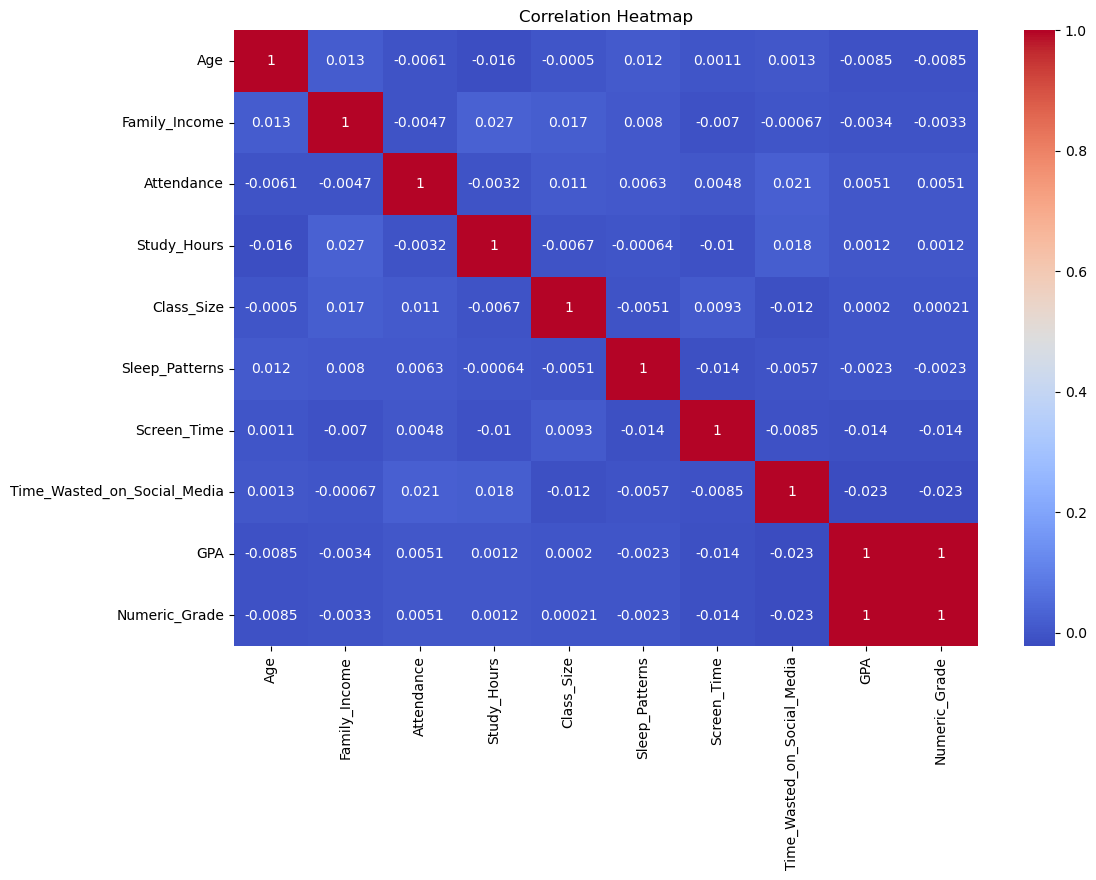

In [16]:
# Visualization 2: Correlation Heatmap
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

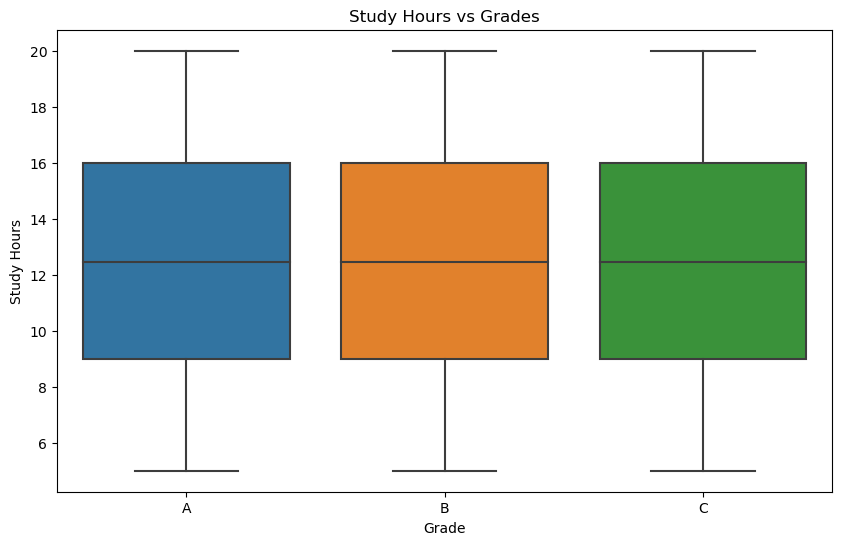

In [17]:
# Visualization 3: Study Hours vs GPA
plt.figure(figsize=(10, 6))
sns.boxplot(x='Grades', y='Study_Hours', data=df, order=sorted(df['Grades'].unique()))
plt.title('Study Hours vs Grades')
plt.xlabel('Grade')
plt.ylabel('Study Hours')
plt.show()

In [18]:
# Sample 5,000 rows from the dataset
df_sampled = df.sample(n=5000, random_state=8)

# Create an interactive box plot
box_plot = alt.Chart(df_sampled).mark_boxplot().encode(
    x='Gender:N',  
    y='GPA:Q',    
    #color='Parental_Education:N', 
    tooltip=['Gender', 'Parental_Education', 'GPA']  
).properties(
    title='Distribution of Student Grades by Demographic Groups',
    width=600,
    height=400
)

# Add interactivity (zoom and pan)
interactive_plot = box_plot.interactive()

# Show the plot
interactive_plot.show()

alt.Chart(...)

In [19]:
fig = px.scatter(
    df,
    x='Study_Hours',
    y='GPA',
    color='Class_Participation',
    hover_data=['Major', 'Grades'],
    title='Study Hours vs GPA (Interactive by Major)'
)

# Save plot as HTML for iframe embedding
fig.write_html("plotly_chart.html")

C:\Users\rjiang\anaconda3\Lib\site-packages\plotly\express\_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



In [20]:
import plotly.express as px

sunburst_data = df.groupby(['School_Type', 'Major', 'Grades']).size().reset_index(name='Count')

# Custom color mapping for grades
grade_colors = {
    'A': '#7572FF',
    'B': '#E45142',
    'C': '#49C89B'
}

# Create sunburst chart
fig = px.sunburst(
    sunburst_data,
    path=['School_Type', 'Major', 'Grades'],
    values='Count',
    title='Sunburst Chart: School Type - Major - Grades',
    color='Grades',
    color_discrete_map=grade_colors
)

fig.write_html("sunburst.html")
